# 🛒 Walmart Retail Sales — Data Preprocessing & EDA Pipeline

---

## 📌 Project Overview

This notebook implements a **complete, submission-ready data preprocessing and EDA pipeline** for the Walmart retail sales dataset.

### 📂 Input Files

| File | Description |
|------|-------------|
| `features.xlsx` | Economic indicators + MarkDown promotions per store/date |
| `stores.csv` | Store metadata (Type, Size) |
| `train.csv` | Weekly sales per department/store |
| `test.csv` | Future dates for prediction |

### 🔄 Enforced Pipeline Order

```
① Load Datasets
② Clean Data          (parse dates, audit nulls)
③ Feature Engineering (combine MarkDown1–5 → MarkDown)
④ Merge All Datasets  → full_df
⑤ Normalize           (MinMaxScaler on full_df ONLY)
⑥ EDA & Visualizations
```

> ⚠️ **Normalization is applied exclusively on `full_df` after all merges are complete.** Normalizing partial DataFrames before merging would cause data leakage and inconsistent scaling across the final feature set.

---

## 📦 Section 1 — Import Libraries

### 🎯 Objective
Import every required library in one place so no cell fails due to a missing import.

### 🧠 Why?
Centralising imports prevents the scattered `import` anti-pattern, makes dependency auditing trivial, and ensures the notebook can be re-run cleanly from the top.

In [9]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── ML preprocessing ─────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Display config ────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported.')

✅ All libraries imported.


---

## 📂 Section 2 — Load Datasets

### 🎯 Objective
Load all four source files into Pandas DataFrames and perform a quick sanity check on shape and columns.

### 🧠 Why?
- `features.xlsx` ships as Excel — `read_excel()` is required.
- Printing shapes immediately catches truncated or empty files before any processing begins.

### ⚙️ What the code does
Loads each file, prints its shape and column list.

In [10]:
# ── Load Excel ────────────────────────────────────────────────────────────────
features_df = pd.read_excel('features.xlsx')

# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df  = pd.read_csv('train.csv')
stores_df = pd.read_csv('stores.csv')
test_df   = pd.read_csv('test.csv')

# ── Quick audit ───────────────────────────────────────────────────────────────
for name, df in [('features_df', features_df), ('train_df', train_df),
                 ('stores_df',  stores_df),   ('test_df',  test_df)]:
    print(f'{name:14s} → shape {str(df.shape):15s}  cols: {df.columns.tolist()}')

features_df    → shape (8190, 12)       cols: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
train_df       → shape (421570, 5)      cols: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
stores_df      → shape (45, 3)          cols: ['Store', 'Type', 'Size']
test_df        → shape (115064, 4)      cols: ['Store', 'Dept', 'Date', 'IsHoliday']


In [11]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [12]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [13]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


---

## 🧹 Section 3 — Data Cleaning

### 🎯 Objective
1. Parse all `Date` columns to `datetime64`.
2. Audit null values across all DataFrames.
3. Verify date coverage between `features_df` and `train_df`.

### 🧠 Why?
- Date columns loaded from files are raw strings. Merging on string dates fails silently when formats differ even slightly.
- Null values in join keys (`Store`, `Date`, `IsHoliday`) cause rows to silently disappear during the merge.
- Date coverage checks reveal whether every training week has a corresponding features row.

### ⚙️ What the code does
- Converts `Date` in `features_df`, `train_df`, and `test_df` using `pd.to_datetime()`.
- Prints total NaN count per DataFrame.
- Computes set-difference between feature dates and training dates.

In [14]:
# ── Parse dates ───────────────────────────────────────────────────────────────
features_df['Date'] = pd.to_datetime(features_df['Date'])
train_df['Date']    = pd.to_datetime(train_df['Date'])

if 'Date' in test_df.columns:
    test_df['Date'] = pd.to_datetime(test_df['Date'])
else:
    print('⚠️  test_df has no Date column. Available:', test_df.columns.tolist())

print('✅ Date columns parsed to datetime64.')

# ── Null audit ────────────────────────────────────────────────────────────────
print('\n── Null counts ──────────────────────────────────')
for name, df in [('features_df', features_df), ('train_df', train_df), ('stores_df', stores_df)]:
    nulls = df.isnull().sum()
    has_nulls = nulls[nulls > 0]
    if has_nulls.empty:
        print(f'  {name:14s}: no nulls')
    else:
        print(f'  {name:14s}: {has_nulls.to_dict()}')

✅ Date columns parsed to datetime64.

── Null counts ──────────────────────────────────
  features_df   : {'MarkDown1': 4158, 'MarkDown2': 5269, 'MarkDown3': 4577, 'MarkDown4': 4726, 'MarkDown5': 4140, 'CPI': 585, 'Unemployment': 585}
  train_df      : no nulls
  stores_df     : no nulls


In [15]:
# ── Date coverage check ───────────────────────────────────────────────────────
feat_dates  = set(features_df['Date'].unique())
train_dates = set(train_df['Date'].unique())
common      = feat_dates & train_dates
only_feat   = feat_dates  - train_dates
only_train  = train_dates - feat_dates

print(f'Dates in features_df         : {len(feat_dates)}')
print(f'Dates in train_df            : {len(train_dates)}')
print(f'Common dates                 : {len(common)}')
print(f'Only in features_df          : {len(only_feat)}')
print(f'Only in train_df             : {len(only_train)}')

if only_train:
    print(f'\n⚠️  {len(only_train)} training dates have no matching features row.')
    print('   These will produce NaN in features after the left-join merge.')
    print('   Sample:', sorted(only_train)[:3])

Dates in features_df         : 182
Dates in train_df            : 143
Common dates                 : 143
Only in features_df          : 39
Only in train_df             : 0


---

## 🔧 Section 4 — Feature Engineering: MarkDown

### 🎯 Objective
Combine `MarkDown1`–`MarkDown5` in `features_df` into a single `MarkDown` column **before** merging.

### 🧠 Why?
- **Dimensionality reduction** — five sparse, correlated columns collapse into one dense feature.
- **Promotional intensity** — the sum captures total discount activity across all markdown categories.
- **NA strategy** — MarkDown data only becomes available from November 2011. Pre-Nov 2011 NaN values represent *zero promotion*, not missing data, so filling with 0 is semantically correct.
- **Negative values** — negative MarkDown figures are data entry artefacts with no real-world meaning; clipping to 0 is the standard approach.

### ⚙️ What the code does
1. Fills `NaN → 0` across all five MarkDown columns.
2. Clips any remaining negatives `→ 0`.
3. Sums columns into a new `MarkDown` feature.
4. Drops the original five columns.

> 📌 This step runs on `features_df` only. Normalization of `MarkDown` happens later on the fully merged `full_df`.

In [16]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Guard: only proceed if all five columns exist
missing_md = [c for c in markdown_cols if c not in features_df.columns]
if missing_md:
    raise KeyError(f'Expected MarkDown columns not found: {missing_md}\n'
                   f'Available: {features_df.columns.tolist()}')

# Step 1 — Fill NA with 0
features_df[markdown_cols] = features_df[markdown_cols].fillna(0)

# Step 2 — Clip negatives to 0
features_df[markdown_cols] = features_df[markdown_cols].clip(lower=0)

# Step 3 — Combine into single feature
features_df['MarkDown'] = features_df[markdown_cols].sum(axis=1)

# Step 4 — Drop originals
features_df.drop(columns=markdown_cols, inplace=True)

print('✅ MarkDown feature engineered.')
print(f'   Range  : [{features_df["MarkDown"].min():.2f}, {features_df["MarkDown"].max():.2f}]')
print(f'   Zeros  : {(features_df["MarkDown"] == 0).sum():,} rows')
print(f'   Non-zero: {(features_df["MarkDown"] > 0).sum():,} rows')
print(f'\n   features_df columns now: {features_df.columns.tolist()}')

✅ MarkDown feature engineered.
   Range  : [0.00, 783529.45]
   Zeros  : 4,140 rows
   Non-zero: 4,050 rows

   features_df columns now: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday', 'MarkDown']


---

## 🔢 Section 5 — Encode Boolean Features

### 🎯 Objective
Convert `IsHoliday` from boolean (`True`/`False`) to integer (`1`/`0`) in both `features_df` and `train_df`.

### 🧠 Why?
- `IsHoliday` is a join key in the upcoming merge. Mismatched types between DataFrames (e.g. `bool` vs `int64`) cause silent row-drops in `pandas.merge()`.
- Integer encoding is required for most scikit-learn estimators.

### ⚙️ What the code does
Casts `IsHoliday` to `int` in both DataFrames so the merge key types are identical.

In [17]:
for name, df in [('features_df', features_df), ('train_df', train_df)]:
    if 'IsHoliday' in df.columns:
        df['IsHoliday'] = df['IsHoliday'].astype(int)
        print(f'  ✅ {name}["IsHoliday"] → int  '
              f'(values: {sorted(df["IsHoliday"].unique())})')
    else:
        print(f'  ⚠️  IsHoliday not found in {name}')

  ✅ features_df["IsHoliday"] → int  (values: [np.int64(0), np.int64(1)])
  ✅ train_df["IsHoliday"] → int  (values: [np.int64(0), np.int64(1)])


---

## 🔗 Section 6 — Merge All Datasets → `full_df`

### 🎯 Objective
Produce one unified flat table — `full_df` — that brings together weekly sales, store metadata, economic indicators, and the `MarkDown` feature.

### 🧠 Why?
ML models train on a single matrix. The three source files are relational: they must be joined correctly before any column-wise operation (normalisation, modelling) is applied.

### ⚙️ Merge Strategy

```
Step 1:  features_df  LEFT JOIN  stores_df      ON [Store]
                      → features_merged

Step 2:  train_df     LEFT JOIN  features_merged ON [Store, Date, IsHoliday]
                      → full_df
```

Starting from `train_df` in Step 2 guarantees **every `Weekly_Sales` record is kept**, even if a features row is missing (it receives NaN, which we then audit).

### ⚠️ Important
Normalization is intentionally deferred to the next section. Scaling partial DataFrames before this merge would produce different [0,1] bounds than scaling the full dataset, leading to inconsistent feature ranges.

In [18]:
# ── Step 1: Attach store metadata to features ─────────────────────────────────
features_merged = features_df.merge(
    stores_df.drop(columns=['Size']),
    on='Store',
    how='left'
)

print(f'features_merged  → shape: {features_merged.shape}')
print(f'columns: {features_merged.columns.tolist()}')

features_merged  → shape: (8190, 9)
columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday', 'MarkDown', 'Type']


In [19]:
# ── Step 2: Join features into training data ──────────────────────────────────
full_df = train_df.merge(
    features_merged,
    on=['Store', 'Date', 'IsHoliday'],
    how='left'
)

print(f'full_df  → shape: {full_df.shape}')
print(f'columns: {full_df.columns.tolist()}')

# ── Verify MarkDown arrived ───────────────────────────────────────────────────
assert 'MarkDown' in full_df.columns, \
    '❌ MarkDown not in full_df — check merge keys or feature engineering step'
print('\n✅ MarkDown present in full_df')

full_df  → shape: (421570, 11)
columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Type']

✅ MarkDown present in full_df


In [20]:
# ── Post-merge null audit ─────────────────────────────────────────────────────
null_counts = full_df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if null_counts.empty:
    print('✅ No NaN values in full_df after merge.')
else:
    print('⚠️  NaN values detected in full_df after merge:')
    print(null_counts.to_string())
    print('\n→ If economic feature columns have NaN, this means some training dates')
    print('  had no corresponding row in features_df (expected for some datasets).')

full_df.head()

✅ No NaN values in full_df after merge.


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown,Type
0,1,1,2010-02-05,24924.50,0,42.31,2.572,211.096358,8.106,0.0,A
1,1,1,2010-02-12,46039.49,1,38.51,2.548,211.242170,8.106,0.0,A
2,1,1,2010-02-19,41595.55,0,39.93,2.514,211.289143,8.106,0.0,A
3,1,1,2010-02-26,19403.54,0,46.63,2.561,211.319643,8.106,0.0,A
4,1,1,2010-03-05,21827.90,0,46.50,2.625,211.350143,8.106,0.0,A


---

## ⚖️ Section 7 — Normalization on `full_df`

### 🎯 Objective
Scale the five continuous features to the [0, 1] range using `MinMaxScaler`, applied **exclusively on `full_df`** after all merges.

### 🧠 Why?
- **Consistency** — scaling on the full dataset ensures all rows see the same global min/max. Scaling before merging would compute bounds on a subset, giving different (wrong) values for the same column after joining.
- **No data leakage** — `fit_transform` is called once per column on the full training set.
- **Model compatibility** — gradient-based models (linear regression, neural networks) and distance-based models (KNN, SVM) require features on comparable scales.

### ⚙️ What the code does
Applies `MinMaxScaler().fit_transform()` to each of `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `MarkDown` in `full_df`. **`Weekly_Sales` is intentionally not scaled** — it is the target variable.

> 🚫 Normalization is **not** applied anywhere else in this notebook.

In [21]:
cols_to_normalize = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown']

# Guard: confirm all columns exist in full_df
missing_norm = [c for c in cols_to_normalize if c not in full_df.columns]
if missing_norm:
    raise KeyError(f'Cannot normalize — columns missing from full_df: {missing_norm}')

# Apply MinMaxScaler once per column on the final merged dataset
scaler = MinMaxScaler()

for col in cols_to_normalize:
    # Fit and transform only on non-null rows; preserve NaN positions
    mask = full_df[col].notna()
    full_df.loc[mask, col] = scaler.fit_transform(
        full_df.loc[mask, col].values.reshape(-1, 1)
    ).flatten()

print('✅ Normalization complete. Columns scaled on full_df:')
print(full_df[cols_to_normalize].describe().round(4))

✅ Normalization complete. Columns scaled on full_df:
       Temperature   Fuel_Price          CPI  Unemployment     MarkDown
count  421570.0000  421570.0000  421570.0000   421570.0000  421570.0000
mean        0.6081       0.4454       0.4462        0.3912       0.0416
std         0.1805       0.2297       0.3871        0.1786       0.0919
min         0.0000       0.0000       0.0000        0.0000       0.0000
25%         0.4769       0.2310       0.0589        0.2887       0.0000
50%         0.6277       0.4910       0.5560        0.3821       0.0000
75%         0.7470       0.6343       0.8536        0.4498       0.0503
max         1.0000       1.0000       1.0000        1.0000       1.0000


In [22]:
# Final verification — all scaled columns should be in [0, 1]
print('── Range check (should all be 0.0 – 1.0) ────────────────')
for col in cols_to_normalize:
    lo = full_df[col].min()
    hi = full_df[col].max()
    ok = '✅' if (round(lo, 6) >= 0 and round(hi, 6) <= 1) else '⚠️'
    print(f'  {ok}  {col:15s}: [{lo:.6f}, {hi:.6f}]')

── Range check (should all be 0.0 – 1.0) ────────────────
  ✅  Temperature    : [0.000000, 1.000000]
  ✅  Fuel_Price     : [0.000000, 1.000000]
  ✅  CPI            : [0.000000, 1.000000]
  ✅  Unemployment   : [0.000000, 1.000000]
  ✅  MarkDown       : [0.000000, 1.000000]


---

## 📋 Section 8 — Final Dataset Summary

### 🎯 Objective
Confirm `full_df` is complete, correctly typed, and contains every expected column before EDA.

### ⚙️ What the code does
Prints shape, dtype table, and a checklist of required columns.

In [23]:
required_cols = [
    'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown', 'Type', 'Size'
]

print('=' * 56)
print('         FINAL full_df SUMMARY')
print('=' * 56)
print(f'  Shape       : {full_df.shape}')
print(f'  Total NaN   : {full_df.isnull().sum().sum()}')
print()
print('── Required Columns ──────────────────────────────────')
for col in required_cols:
    status = '✅' if col in full_df.columns else '❌ MISSING'
    dtype  = str(full_df[col].dtype) if col in full_df.columns else 'N/A'
    print(f'  {status}  {col:15s}  dtype: {dtype}')

print()
print('── All Columns ───────────────────────────────────────')
print(full_df.columns.tolist())

         FINAL full_df SUMMARY
  Shape       : (421570, 11)
  Total NaN   : 0

── Required Columns ──────────────────────────────────
  ✅  Store            dtype: int64
  ✅  Dept             dtype: int64
  ✅  Date             dtype: datetime64[ns]
  ✅  Weekly_Sales     dtype: float64
  ✅  IsHoliday        dtype: int64
  ✅  Temperature      dtype: float64
  ✅  Fuel_Price       dtype: float64
  ✅  CPI              dtype: float64
  ✅  Unemployment     dtype: float64
  ✅  MarkDown         dtype: float64
  ✅  Type             dtype: object
  ❌ MISSING  Size             dtype: N/A

── All Columns ───────────────────────────────────────
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Type']


In [24]:
full_df.describe().round(4)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown
count,421570.0000,421570.0000,421570,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000
mean,22.2005,44.2603,2011-06-18 08:30:31.963375104,15981.2581,0.0704,0.6081,0.4454,0.4462,0.3912,0.0416
min,1.0000,1.0000,2010-02-05 00:00:00,-4988.9400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,11.0000,18.0000,2010-10-08 00:00:00,2079.6500,0.0000,0.4769,0.2310,0.0589,0.2887,0.0000
50%,22.0000,37.0000,2011-06-17 00:00:00,7612.0300,0.0000,0.6277,0.4910,0.5560,0.3821,0.0000
75%,33.0000,74.0000,2012-02-24 00:00:00,20205.8525,0.0000,0.7470,0.6343,0.8536,0.4498,0.0503
max,45.0000,99.0000,2012-10-26 00:00:00,693099.3600,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
std,12.7853,30.4921,NaN,22711.1835,0.2558,0.1805,0.2297,0.3871,0.1786,0.0919


In [25]:
full_df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown,Type
0,1,1,2010-02-05,24924.50,0,0.434149,0.050100,0.840500,0.405118,0.0,A
1,1,1,2010-02-12,46039.49,1,0.396967,0.038076,0.841941,0.405118,0.0,A
2,1,1,2010-02-19,41595.55,0,0.410861,0.021042,0.842405,0.405118,0.0,A
3,1,1,2010-02-26,19403.54,0,0.476419,0.044589,0.842707,0.405118,0.0,A
4,1,1,2010-03-05,21827.90,0,0.475147,0.076653,0.843008,0.405118,0.0,A
5,1,1,2010-03-12,21043.39,0,0.585616,0.097695,0.843310,0.405118,0.0,A
6,1,1,2010-03-19,22136.64,0,0.554207,0.124248,0.841679,0.405118,0.0,A
7,1,1,2010-03-26,26229.21,0,0.523581,0.130261,0.839726,0.405118,0.0,A
8,1,1,2010-04-02,57258.43,0,0.629452,0.123747,0.837773,0.376557,0.0,A
9,1,1,2010-04-09,42960.91,0,0.664579,0.149299,0.835819,0.376557,0.0,A


---

## 🚨 Section 9 — Outlier Detection

### 🎯 Objective
Visualise the distribution and outliers of the four normalised economic features in `full_df` using boxplots and histograms.

### 🧠 Why?
- Outliers in features like `CPI` or `Unemployment` can skew model training.
- Because normalisation has already been applied, axes now show [0, 1] values — making comparisons across features straightforward.
- We visualise before deciding to remove; not all statistical outliers represent errors.

### ⚙️ What the code does
Draws 2×2 boxplots and 2×2 histograms (with KDE) for `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`.

### 📊 Insight
Points outside the whiskers in boxplots are IQR-based outliers. A KDE that skews heavily in the histogram signals that the feature may need log-transformation for linear models.

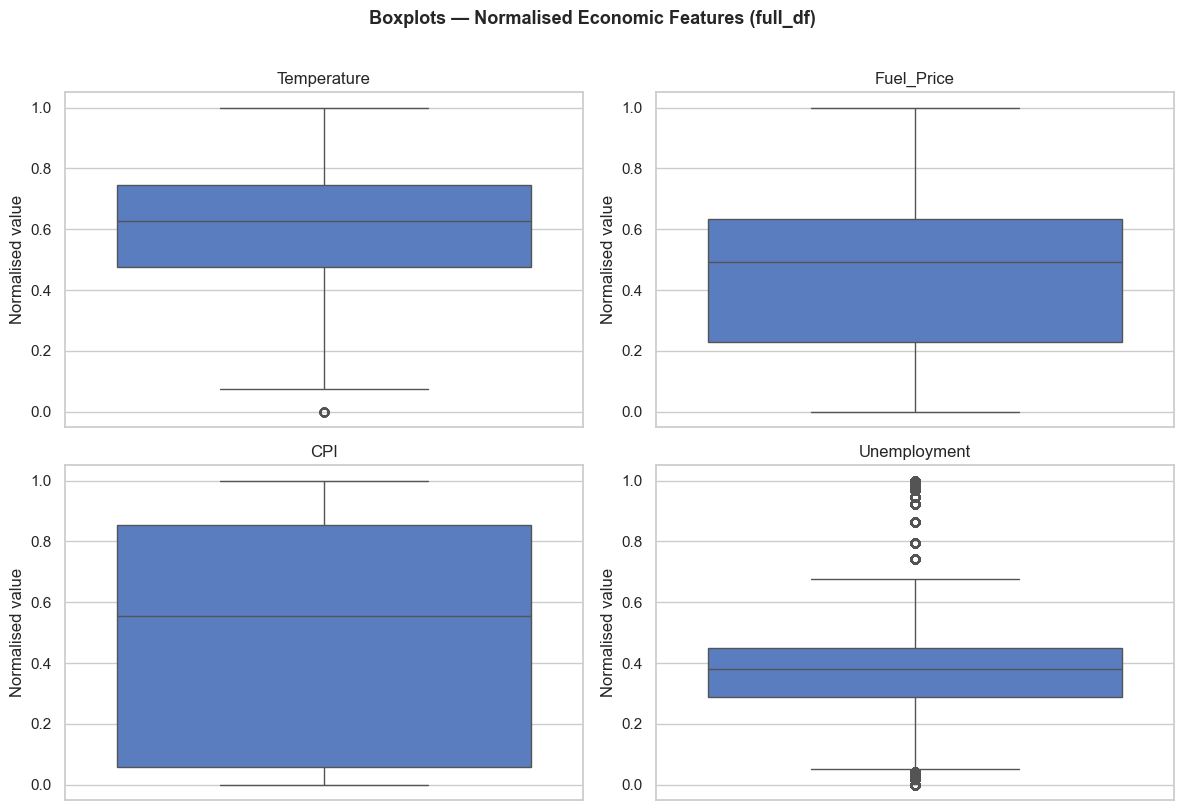

In [26]:
econ_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplots — Normalised Economic Features (full_df)',
             fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(econ_cols):
    ax = axes[i // 2, i % 2]
    sns.boxplot(y=full_df[col].dropna(), ax=ax)
    ax.set_title(col)
    ax.set_ylabel('Normalised value')

plt.tight_layout()
plt.show()

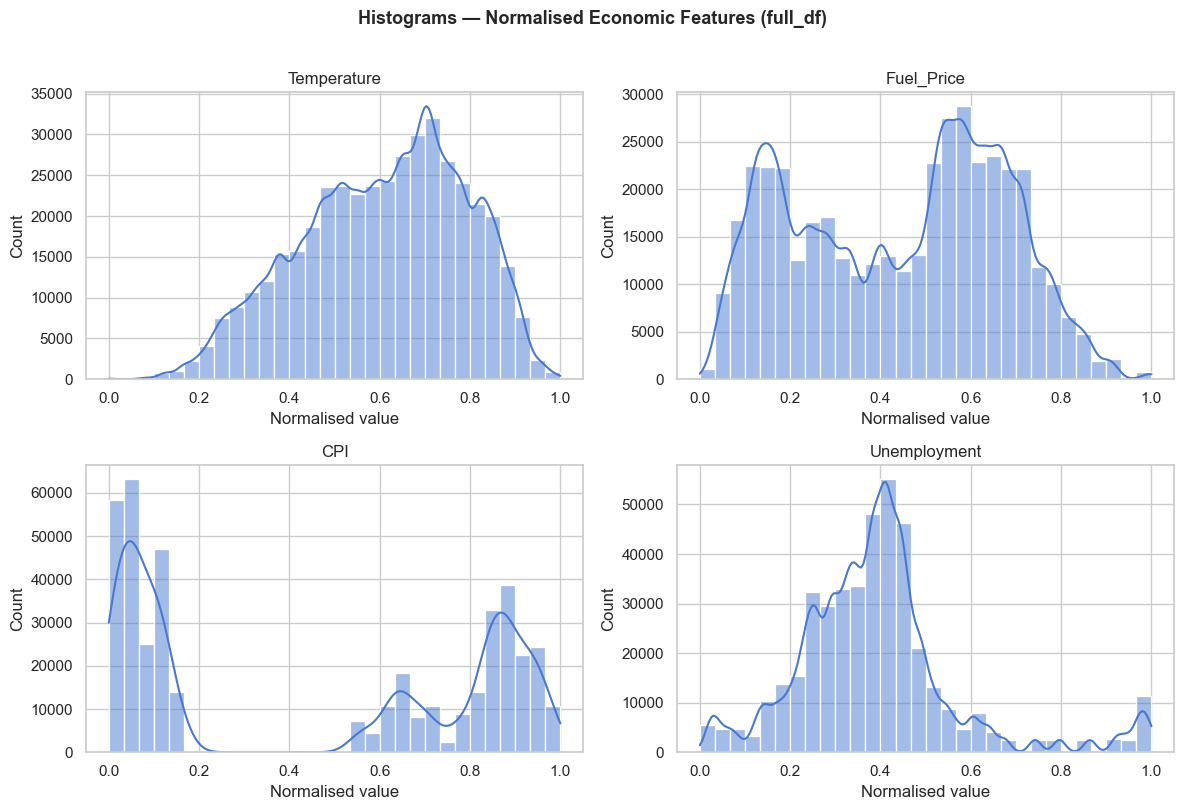

In [27]:
# ── Histograms ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms — Normalised Economic Features (full_df)',
             fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(econ_cols):
    ax = axes[i // 2, i % 2]
    sns.histplot(full_df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Normalised value')

plt.tight_layout()
plt.show()

---

## 📊 Section 10 — EDA: Weekly Sales vs Holiday

### 🎯 Objective
Understand how `IsHoliday` affects `Weekly_Sales`.

### 🧠 Why?
Holiday weeks are expected to produce higher sales due to increased consumer spending around major events (Thanksgiving, Christmas). Confirming this validates the feature and informs model weighting strategies.

### ⚙️ What the code does
1. **Boxplot** — shows the full distribution of weekly sales for each holiday flag value.
2. **Bar chart** — shows mean sales per group for a quick summary comparison.

### 📊 Insight
If the holiday boxplot median is visibly higher, holiday status is a strong predictor and should be weighted appropriately in the model.

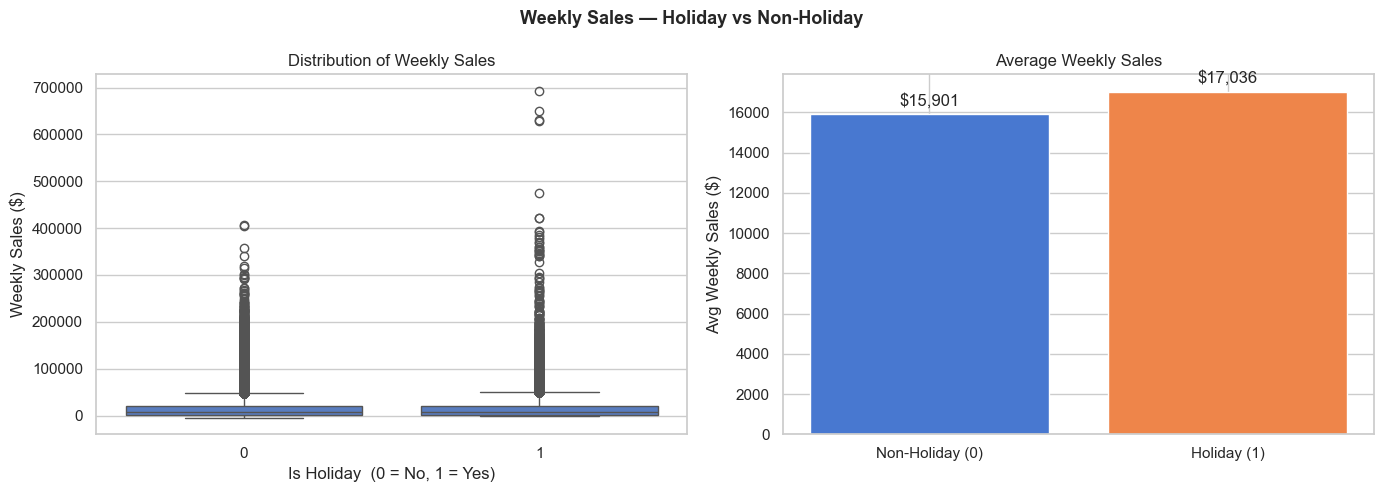


📊 Mean Weekly Sales by Holiday:
IsHoliday
Non-Holiday    $15,901.45
Holiday        $17,035.82


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Sales — Holiday vs Non-Holiday', fontsize=13, fontweight='bold')

# ── Boxplot ───────────────────────────────────────────────────────────────────
sns.boxplot(
    x='IsHoliday', y='Weekly_Sales',
    data=full_df, ax=axes[0]
)
axes[0].set_title('Distribution of Weekly Sales')
axes[0].set_xlabel('Is Holiday  (0 = No, 1 = Yes)')
axes[0].set_ylabel('Weekly Sales ($)')

# ── Mean bar chart ────────────────────────────────────────────────────────────
avg = full_df.groupby('IsHoliday')['Weekly_Sales'].mean()
bars = axes[1].bar(
    ['Non-Holiday (0)', 'Holiday (1)'],
    avg.values,
    color=sns.color_palette('muted')[:2]
)
axes[1].bar_label(bars, fmt='${:,.0f}', padding=4)
axes[1].set_title('Average Weekly Sales')
axes[1].set_ylabel('Avg Weekly Sales ($)')

plt.tight_layout()
plt.show()

print('\n📊 Mean Weekly Sales by Holiday:')
print(avg.rename({0: 'Non-Holiday', 1: 'Holiday'}).apply(lambda x: f'${x:,.2f}').to_string())

---

## 📊 Section 11 — EDA: MarkDown vs Weekly Sales (Before vs After Nov 2011)

### 🎯 Objective
Compare the relationship between `MarkDown` and `Weekly_Sales` across the key temporal boundary of **November 2011**, when MarkDown data became reliably populated.

### 🧠 Why?
Before Nov 2011, most `MarkDown` values are 0 (filled during feature engineering). After Nov 2011, real promotional data is present. Splitting at this boundary isolates whether promotions genuinely drive incremental sales.

### ⚙️ What the code does
Splits `full_df` into `before_df` / `after_df` and renders side-by-side scatter plots.

### 📊 Insight
A positive slope in the *After Nov 2011* scatter — absent in the *Before* plot — would confirm that MarkDown is a meaningful sales driver.

Records before Nov 2011 : 267,184
Records from  Nov 2011+ : 154,386


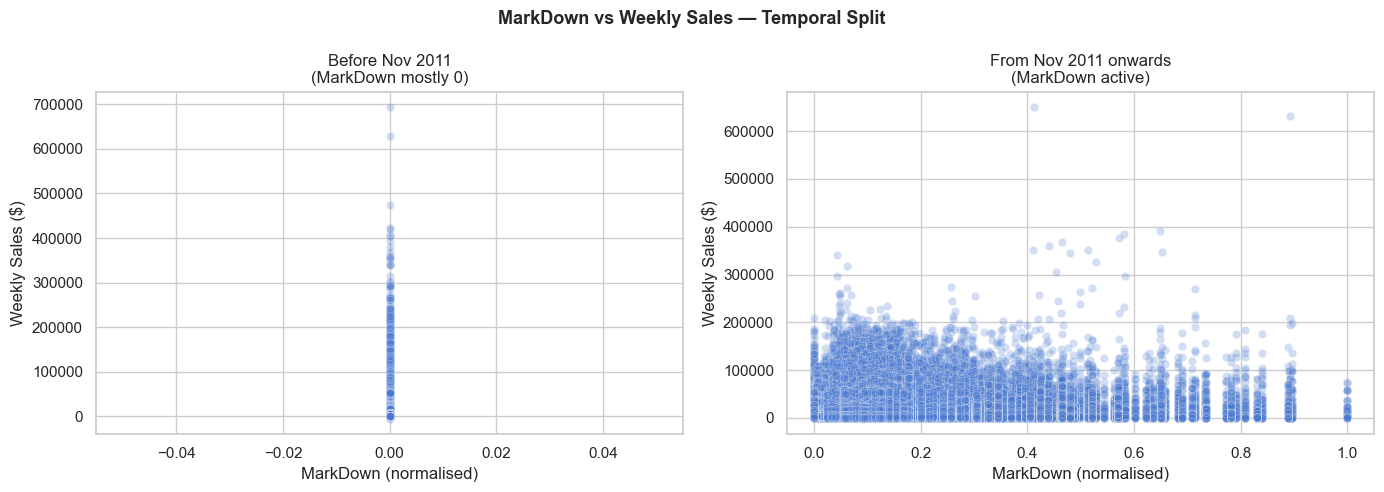

In [29]:
before_df = full_df[full_df['Date'] <  '2011-11-01']
after_df  = full_df[full_df['Date'] >= '2011-11-01']

print(f'Records before Nov 2011 : {len(before_df):,}')
print(f'Records from  Nov 2011+ : {len(after_df):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MarkDown vs Weekly Sales — Temporal Split',
             fontsize=13, fontweight='bold')

for ax, df, title in [
    (axes[0], before_df, 'Before Nov 2011\n(MarkDown mostly 0)'),
    (axes[1], after_df,  'From Nov 2011 onwards\n(MarkDown active)')
]:
    sns.scatterplot(
        x='MarkDown', y='Weekly_Sales',
        data=df.dropna(subset=['MarkDown', 'Weekly_Sales']),
        alpha=0.25, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('MarkDown (normalised)')
    ax.set_ylabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

---

## 📊 Section 12 — EDA: MarkDown vs Weekly Sales (Holiday Split)

### 🎯 Objective
Determine whether promotional activity (`MarkDown`) (after NOV 2011) has a stronger effect on sales during **holiday** vs **non-holiday** weeks.

### 🧠 Why?
Promotions are typically amplified during holiday seasons. If holiday scatter shows a steeper MarkDown–sales relationship, this interaction term could be a valuable engineered feature.

### 📊 Insight
Denser scatter at higher MarkDown values during holidays would indicate that promotions and holidays jointly amplify sales.

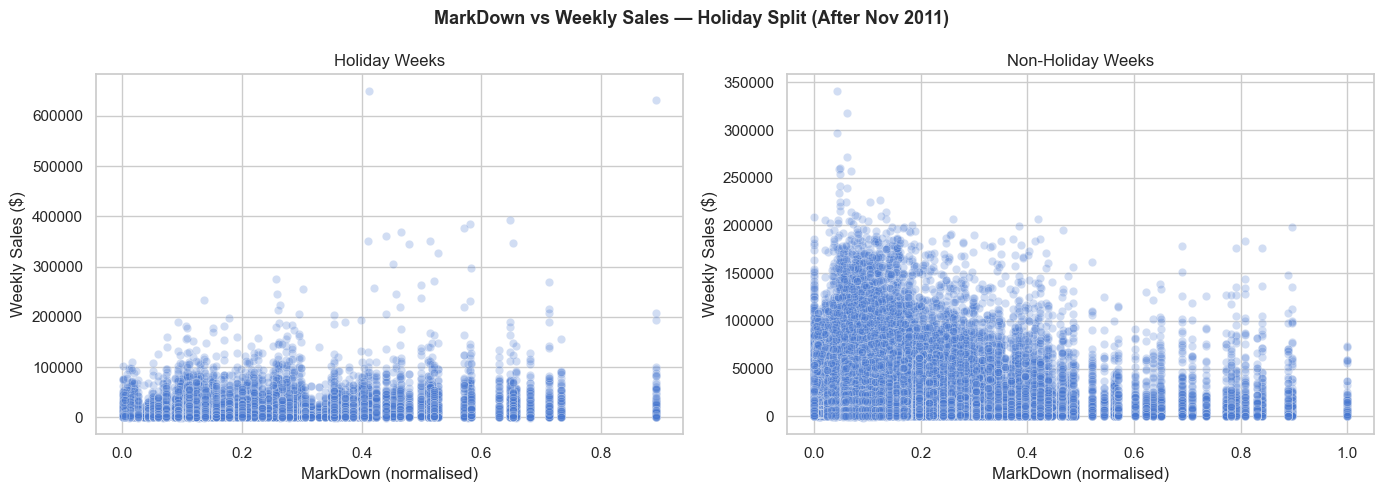

In [30]:
# Ensure datetime
full_df["Date"] = pd.to_datetime(full_df["Date"])

# ✅ Filter AFTER Nov 2011
after_df = full_df[full_df["Date"] >= "2011-11-01"]

# Split based on holiday
holiday_df     = after_df[after_df['IsHoliday'] == 1]
non_holiday_df = after_df[after_df['IsHoliday'] == 0]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MarkDown vs Weekly Sales — Holiday Split (After Nov 2011)',
             fontsize=13, fontweight='bold')

for ax, df, title in [
    (axes[0], holiday_df,     'Holiday Weeks'),
    (axes[1], non_holiday_df, 'Non-Holiday Weeks')
]:
    sns.scatterplot(
        x='MarkDown', y='Weekly_Sales',
        data=df.dropna(subset=['MarkDown', 'Weekly_Sales']),
        alpha=0.25, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('MarkDown (normalised)')
    ax.set_ylabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

---

## 📊 Section 13 — EDA: Economic Features vs Weekly Sales (Holiday Split)

### 🎯 Objective
Analyse how `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment` relate to `Weekly_Sales`, separately for holiday and non-holiday weeks.

### 🧠 Why?
- **Temperature** — seasonal demand patterns may lift or suppress certain product categories.
- **Fuel Price** — higher fuel costs can reduce trip frequency.
- **CPI** — tracks consumer purchasing power; rising CPI erodes real spending.
- **Unemployment** — high unemployment directly reduces disposable income.

Splitting by `IsHoliday` reveals whether these macro effects are muted or amplified during peak retail periods.

### 📊 Insight
Features with a visible positive or negative slope suggest linear predictability. Features with flat, noisy scatter may need polynomial or interaction terms to contribute meaningfully.

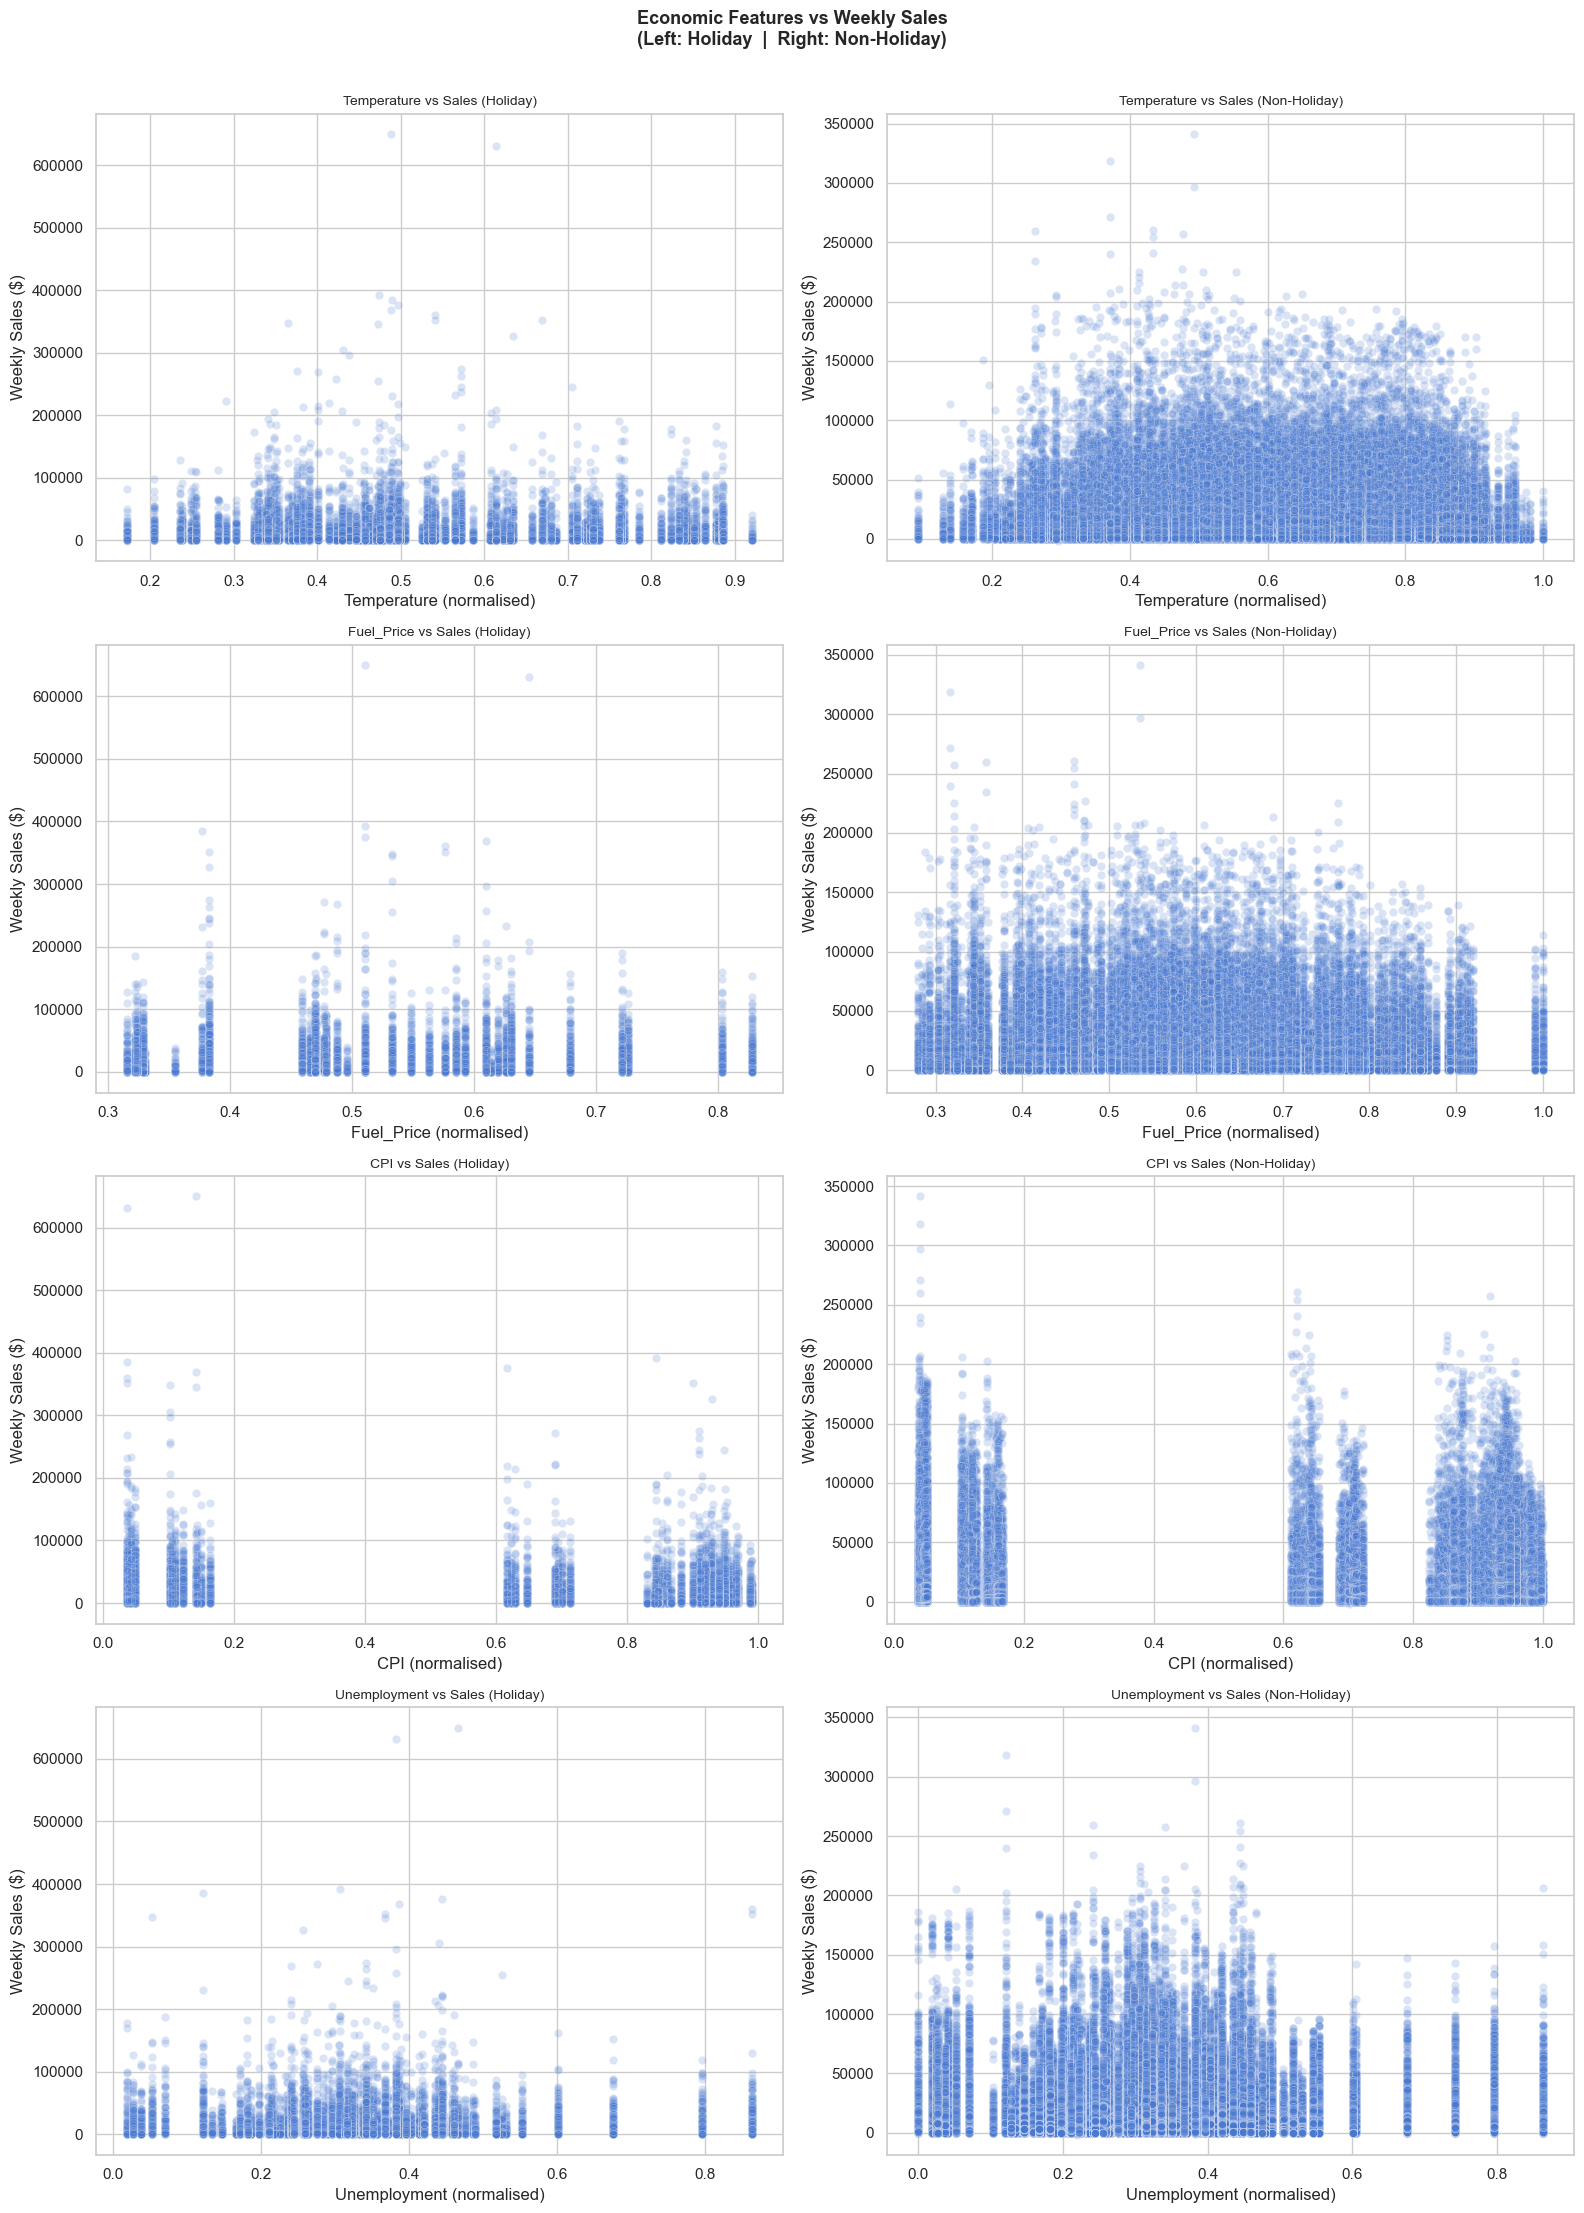

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle('Economic Features vs Weekly Sales\n(Left: Holiday  |  Right: Non-Holiday)',
             fontsize=13, fontweight='bold', y=1.005)

for i, feature in enumerate(econ_cols):
    for j, (df, label) in enumerate([
        (holiday_df,     f'{feature} vs Sales (Holiday)'),
        (non_holiday_df, f'{feature} vs Sales (Non-Holiday)')
    ]):
        ax = axes[i, j]
        plot_data = df.dropna(subset=[feature, 'Weekly_Sales'])
        sns.scatterplot(
            x=feature, y='Weekly_Sales',
            data=plot_data, alpha=0.2, ax=ax
        )
        ax.set_title(label, fontsize=10)
        ax.set_xlabel(f'{feature} (normalised)')
        ax.set_ylabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

---

## ✅ Section 14 — Pipeline Completion Checklist

### 🎯 Objective
Programmatically confirm every pipeline stage completed correctly, providing a clear green-light before model training.

### ⚙️ What the code does
Runs assertions on `full_df` and prints a pass/fail report for each requirement.

In [32]:
checks = []

def check(label, condition, detail=''):
    status = '✅ PASS' if condition else '❌ FAIL'
    checks.append((label, condition))
    print(f'  {status}  {label}' + (f'  ({detail})' if detail else ''))

print('═' * 58)
print('         PIPELINE COMPLETION CHECKLIST')
print('═' * 58)

check('full_df created',
      'full_df' in dir(),
      f'shape={full_df.shape}')

check('Weekly_Sales present',
      'Weekly_Sales' in full_df.columns)

check('MarkDown present',
      'MarkDown' in full_df.columns)

check('MarkDown1–5 dropped',
      all(f'MarkDown{i}' not in full_df.columns for i in range(1, 6)))

check('Store Type present',
      'Type' in full_df.columns)

check('IsHoliday is int',
      full_df['IsHoliday'].dtype in ['int32', 'int64'])

check('Date is datetime',
      str(full_df['Date'].dtype).startswith('datetime'))

for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown']:
    lo = full_df[col].min()
    hi = full_df[col].max()
    check(f'{col} normalised [0,1]',
          round(lo, 4) >= 0 and round(hi, 4) <= 1,
          f'min={lo:.4f}, max={hi:.4f}')

check('Weekly_Sales NOT normalised',
      full_df['Weekly_Sales'].max() > 1,
      'target variable kept on original scale')

print('─' * 58)
n_pass = sum(c for _, c in checks)
n_fail = len(checks) - n_pass
print(f'  Result: {n_pass}/{len(checks)} checks passed   ({n_fail} failed)')
if n_fail == 0:
    print('\n  🎉 full_df is clean and ready for ML model training.')
else:
    print('\n  ⚠️  Fix failing checks before proceeding to model training.')

══════════════════════════════════════════════════════════
         PIPELINE COMPLETION CHECKLIST
══════════════════════════════════════════════════════════
  ✅ PASS  full_df created  (shape=(421570, 11))
  ✅ PASS  Weekly_Sales present
  ✅ PASS  MarkDown present
  ✅ PASS  MarkDown1–5 dropped
  ✅ PASS  Store Type present
  ✅ PASS  IsHoliday is int
  ✅ PASS  Date is datetime
  ✅ PASS  Temperature normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  Fuel_Price normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  CPI normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  Unemployment normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  MarkDown normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  Weekly_Sales NOT normalised  (target variable kept on original scale)
──────────────────────────────────────────────────────────
  Result: 13/13 checks passed   (0 failed)

  🎉 full_df is clean and ready for ML model training.


## 🚨 Outlier Handling Strategy

In this step, we handle outliers in the dataset.

### 🎯 Objective
We aim to reduce the impact of extreme values in **economic features** while preserving meaningful business-driven variations.

---

### 🧠 Important Design Decision

Not all outliers are errors. In this dataset:

- 📈 `Weekly_Sales` outliers often represent **holiday demand spikes**
- 📢 `MarkDown` outliers represent **real promotional campaigns**
- 🌡 Economic indicators may contain **noise or measurement extremes**

👉 Therefore, we do NOT remove all outliers blindly.

---

### ⚙️ Strategy Used

We apply **IQR-based capping (not deletion)** for selected features:

- Temperature  
- Fuel_Price  
- CPI  
- Unemployment  

This approach:
- Preserves data size
- Reduces extreme distortion
- Keeps business-relevant patterns intact

---

### 📊 Why capping instead of removing?

- Removing rows can destroy important holiday/promotional cases
- Capping keeps dataset consistent for machine learning models
- More stable for regression-based algorithms

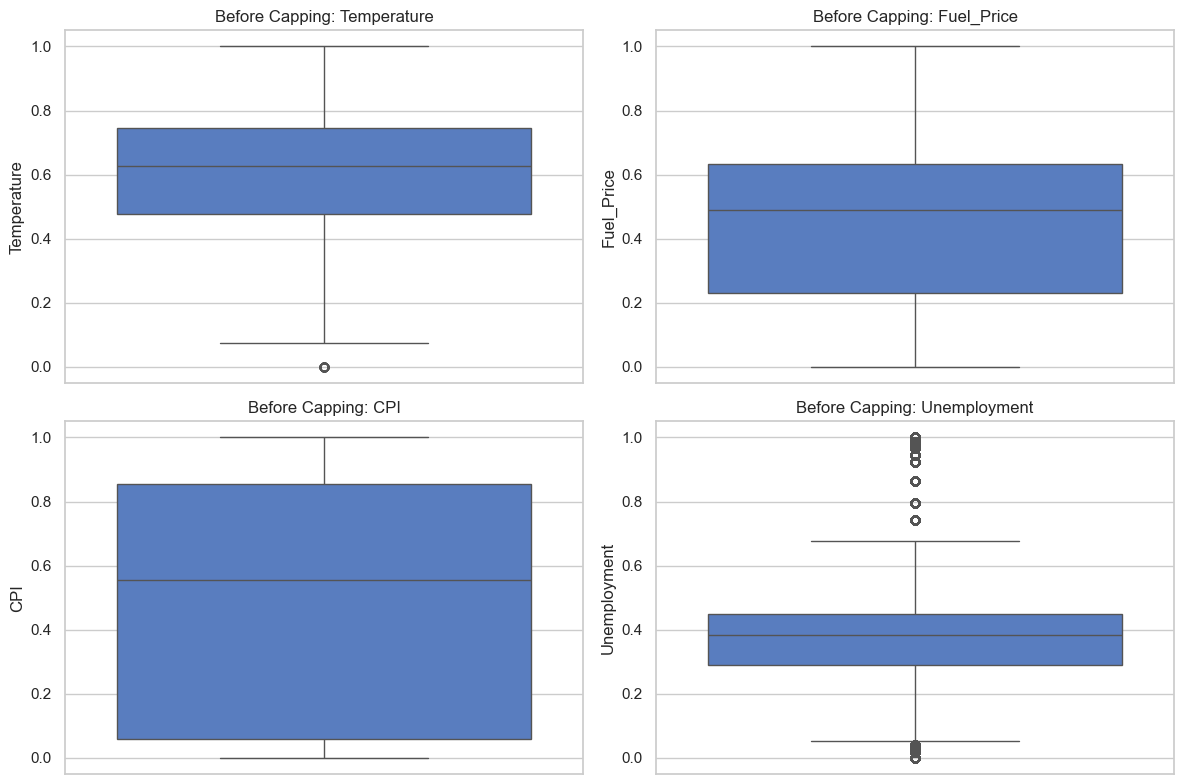

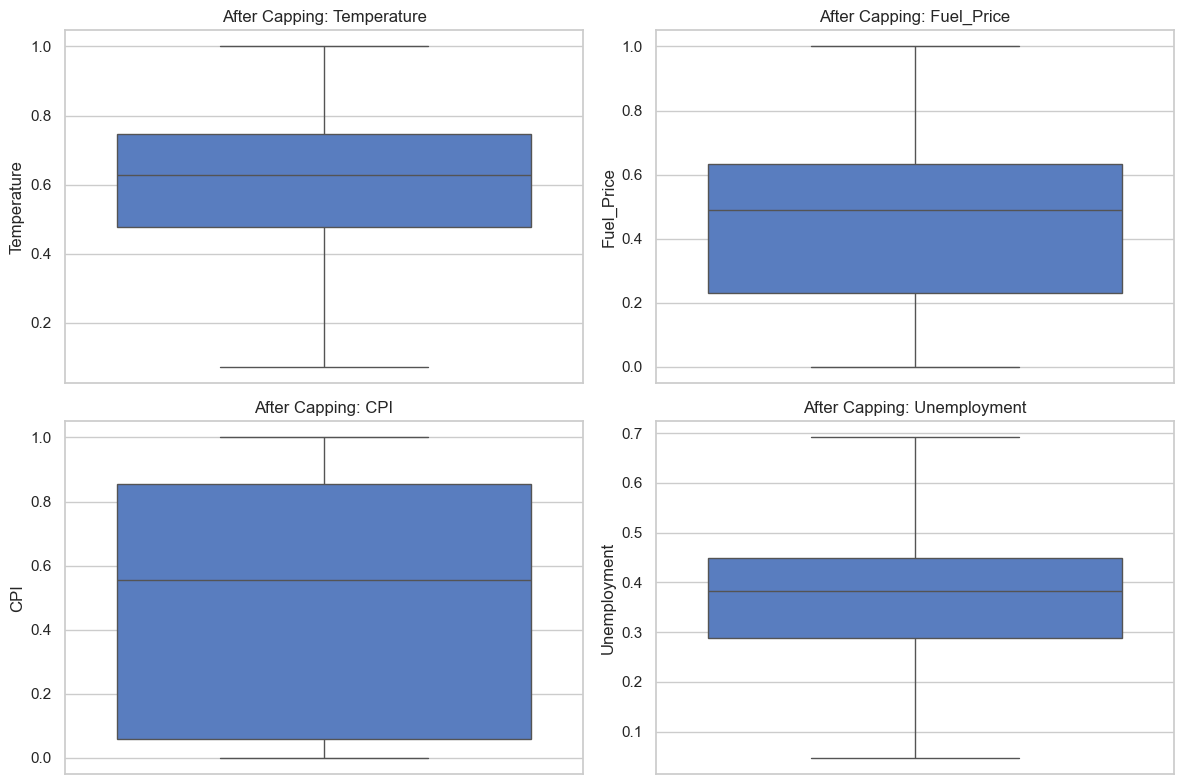

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Before visualization (optional)
# -----------------------------
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=full_df[col])
    plt.title(f"Before Capping: {col}")

plt.tight_layout()
plt.show()


# -----------------------------
# IQR CAPPING FUNCTION
# -----------------------------
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


# Apply only to economic features (NOT sales, NOT markdown)
for col in num_cols:
    cap_outliers(full_df, col)


# -----------------------------
# After visualization
# -----------------------------
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=full_df[col])
    plt.title(f"After Capping: {col}")

plt.tight_layout()
plt.show()

---

# 🌲 Section 15 — Machine Learning: Random Forest Regression

---

## 🎯 Objective

Train a **Random Forest Regressor** to predict `Weekly_Sales` using the fully preprocessed `full_df` dataset.

### 🧠 Why Random Forest?

Random Forest is an **ensemble learning** method that builds multiple decision trees on random subsets of the data and averages their predictions. It is an excellent first choice for this dataset because:

- ✅ **Handles mixed feature types** — numeric, encoded categorical (Store Type), and binary flags (IsHoliday) all work natively
- ✅ **Robust to outliers** — tree splits are rank-based, not magnitude-based
- ✅ **No assumptions about normality** — the target `Weekly_Sales` is right-skewed; Random Forest is unaffected
- ✅ **Built-in feature importance** — measures contribution of each variable without additional tooling
- ✅ **Low risk of overfitting** — bagging and feature subsampling naturally regularise the ensemble

### 📋 Pipeline Overview

```
full_df
 ├── Feature selection  →  X  (drop target, date, leakage cols)
 ├── Target extraction  →  y  (Weekly_Sales)
 ├── Train/Test Split   →  80 % train | 20 % test
 ├── Model training     →  RandomForestRegressor(n_estimators=100)
 └── Evaluation         →  MAE · RMSE · R²
```


## 📦 Section 15.1 — ML Library Imports

### 🎯 Objective
Import all scikit-learn components required for model training and evaluation.

### 🧠 Why this step is needed
Keeping ML-specific imports separate from preprocessing imports makes the notebook modular — the EDA sections can be run independently of the modelling sections.

### ⚙️ What the code does
Imports `RandomForestRegressor`, train/test split utility, and the three evaluation metric functions (`MAE`, `MSE` for RMSE, `R²`).


In [34]:
# ── ML-specific imports ───────────────────────────────────────────────────────
from sklearn.ensemble          import RandomForestRegressor
from sklearn.model_selection   import train_test_split
from sklearn.metrics           import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print('✅ ML libraries imported.')


✅ ML libraries imported.


## 🔍 Section 15.2 — Feature Selection

### 🎯 Objective
Select the correct set of input features (`X`) and target variable (`y`), while removing columns that would cause **data leakage** or are **non-numeric identifiers**.

### 🧠 Why this step is needed

Including the wrong columns in `X` can silently destroy model validity:

| Column | Decision | Reason |
|--------|----------|---------|
| `Weekly_Sales` | ❌ **Target — excluded from X** | This is what we predict |
| `Date` | ❌ **Dropped** | Raw datetime is not numeric; temporal info is already captured via month/week features |
| `Type` | ✅ **One-hot encoded → kept** | Store type (A/B/C) is a nominal categorical predictor |
| `Store` | ✅ **One-hot encoded → kept** | Store ID is a nominal identifier — not an ordered value |
| `Dept` | ✅ **One-hot encoded → kept** | Department ID is a nominal identifier — not an ordered value |

### 🧠 Why `Store` and `Dept` must be one-hot encoded

`Store` and `Dept` are **nominal categorical identifiers** — the integer labels (1, 2, 3 …) carry no ordinal meaning. Passing them as raw integers implies a false mathematical relationship: that Store 10 is "twice" Store 5, or that Department 40 is "between" Departments 30 and 50. This can mislead tree splits and linear models alike.

One-hot encoding converts each store/department into a binary indicator column, allowing the model to learn a **separate, independent effect** for each store and department — which is the correct representation for nominal categories.

All remaining columns (`IsHoliday`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `MarkDown`, `Size`) are continuous or binary numeric features and are retained as-is.

### ⚙️ What the code does
1. Drops `Date` (non-numeric) and `Weekly_Sales` (target) from feature matrix
2. One-hot encodes `Type`, `Store`, and `Dept` with `pd.get_dummies(drop_first=True)` to avoid multicollinearity
3. Fills any residual NaN values with column medians to ensure a clean numeric matrix
4. Prints the final feature list for transparency


In [35]:
# ── Target variable ───────────────────────────────────────────────────────────
y = full_df['Weekly_Sales'].copy()

# ── Feature matrix: drop target and non-numeric date ─────────────────────────
drop_cols = ['Weekly_Sales', 'Date']
X_raw = full_df.drop(columns=[c for c in drop_cols if c in full_df.columns])

# ── One-hot encode nominal categorical columns ────────────────────────────────
#    Store and Dept are identifiers — not ordered values. Type is also nominal.
#    Using drop_first=True avoids perfect multicollinearity in each group.
cat_cols = [c for c in ['Type', 'Store', 'Dept'] if c in X_raw.columns]
if cat_cols:
    X_raw = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
    print(f'✅ One-hot encoded categorical columns: {cat_cols}')

# ── Fill any residual NaN with column median ──────────────────────────────────
null_before = X_raw.isnull().sum().sum()
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
null_after  = X_raw.isnull().sum().sum()

if null_before > 0:
    print(f'⚠️  Filled {null_before} NaN values with column medians → {null_after} remaining')
else:
    print('✅ No NaN values — feature matrix is clean.')

X = X_raw.copy()

print(f'\n── Feature Matrix ──────────────────────────────────')
print(f'  Shape : {X.shape}  ({X.shape[0]:,} rows × {X.shape[1]} features)')
print(f'  Target: y  shape = {y.shape}')
print(f'\n  Continuous / binary features (sample):')
base_cols = ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Size']
for col in base_cols:
    if col in X.columns:
        print(f'    • {col}  (dtype: {X[col].dtype})')
enc_cols = [c for c in X.columns if c not in base_cols]
print(f'\n  One-hot encoded columns  : {len(enc_cols)}  (Store_*, Dept_*, Type_*)')
print(f'  Total features           : {X.shape[1]}')


✅ One-hot encoded categorical columns: ['Type', 'Store', 'Dept']
✅ No NaN values — feature matrix is clean.

── Feature Matrix ──────────────────────────────────
  Shape : (421570, 132)  (421,570 rows × 132 features)
  Target: y  shape = (421570,)

  Continuous / binary features (sample):
    • IsHoliday  (dtype: int64)
    • Temperature  (dtype: float64)
    • Fuel_Price  (dtype: float64)
    • CPI  (dtype: float64)
    • Unemployment  (dtype: float64)
    • MarkDown  (dtype: float64)

  One-hot encoded columns  : 126  (Store_*, Dept_*, Type_*)
  Total features           : 132


In [51]:
import pandas as pd

pd.set_option('display.max_columns', None)

sorted_cols = sorted([col for col in X.columns if 'dept_1' in col])

X_raw[sorted_cols]

""
0
1
2
3
4
...
421565
421566
421567
421568


## ✂️ Section 15.3 — Train / Test Split

### 🎯 Objective
Partition the dataset into training and held-out test sets to obtain an **unbiased estimate** of model generalisation performance.

### 🧠 Why this step is needed
If we evaluate on the same data used for training, the model will appear to perform perfectly — but fail on unseen data. Holding out 20% of the data before training ensures the evaluation metrics reflect real-world predictive power.

### ⚙️ What the code does
- `test_size=0.20` → 80% training / 20% test
- `random_state=42` → makes the split deterministic and reproducible
- Prints resulting shapes for verification

### 📊 Interpretation
An 80/20 split is the standard for datasets of this size (~420K rows). It gives the model enough data to learn complex store/department patterns while reserving a statistically meaningful test pool.


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= 42
)

print('✅ Train / Test split complete.')
print(f'  Training set : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Test set     : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'  Features     : {X_train.shape[1]}')
print(f'\n  Training Weekly_Sales range : ${y_train.min():,.2f} – ${y_train.max():,.2f}')
print(f'  Test     Weekly_Sales range : ${y_test.min():,.2f} – ${y_test.max():,.2f}')


✅ Train / Test split complete.
  Training set : 337,256 rows  (80.0%)
  Test set     :  84,314 rows  (20.0%)
  Features     : 132

  Training Weekly_Sales range : $-4,988.94 – $693,099.36
  Test     Weekly_Sales range : $-3,924.00 – $422,306.25


## 🌲 Section 15.4 — Model Training: Random Forest Regressor

### 🎯 Objective
Train a `RandomForestRegressor` on the training split and confirm convergence.

### 🧠 Why this configuration?

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| `n_estimators` | `100` | Industry-standard default; balances accuracy and training time. More trees reduce variance without increasing bias. |
| `max_depth` | `None` | Trees grow fully — Random Forest's bagging already prevents overfitting without depth restriction. |
| `n_jobs` | `-1` | Uses all CPU cores for parallel tree building — critical for large datasets. |
| `random_state` | `42` | Ensures reproducibility across runs. |

### ⚙️ What the code does
Instantiates and fits the model on `(X_train, y_train)`. Training time is printed to give context for the dataset size.


In [38]:
import time

print('🌲 Training Random Forest Regressor ...')
print('   (n_estimators=100 · n_jobs=-1 · random_state=42)\n')

rf_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1
)

t0 = time.time()
rf_model.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'✅ Model training complete in {elapsed:.1f} seconds.')
print(f'   Trees built       : {rf_model.n_estimators}')
print(f'   Input features    : {rf_model.n_features_in_}')
print(f'   Feature names     : {list(rf_model.feature_names_in_)}')


🌲 Training Random Forest Regressor ...
   (n_estimators=100 · n_jobs=-1 · random_state=42)

✅ Model training complete in 288.7 seconds.
   Trees built       : 100
   Input features    : 132
   Feature names     : ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Type_B', 'Type_C', 'Store_2', 'Store_3', 'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9', 'Store_10', 'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15', 'Store_16', 'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21', 'Store_22', 'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27', 'Store_28', 'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33', 'Store_34', 'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39', 'Store_40', 'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45', 'Dept_2', 'Dept_3', 'Dept_4', 'Dept_5', 'Dept_6', 'Dept_7', 'Dept_8', 'Dept_9', 'Dept_10', 'Dept_11', 'Dept_12', 'Dept_13', 'Dept_14', 'Dept_16', 'Dept_17', 'Dept_18', '

## 📊 Section 15.5 — Model Evaluation

### 🎯 Objective
Quantify the model's predictive accuracy on the **held-out test set** using three complementary metrics.

### 🧠 Why three metrics?

| Metric | Formula | What it measures | Units |
|--------|---------|-----------------|-------|
| **MAE** (Mean Absolute Error) | `mean(|y - ŷ|)` | Average dollar error per prediction — easy to interpret | $ |
| **RMSE** (Root Mean Squared Error) | `√mean((y - ŷ)²)` | Penalises large errors more heavily than MAE — sensitive to outliers | $ |
| **R²** (Coefficient of Determination) | `1 - SS_res/SS_tot` | Proportion of variance explained; 1.0 = perfect, 0.0 = baseline mean | dimensionless |

Together they give a **full picture**: MAE for typical accuracy, RMSE for worst-case sensitivity, R² for overall explanatory power.

### ⚙️ What the code does
1. Runs `rf_model.predict(X_test)` on the held-out set
2. Computes all three metrics
3. Also evaluates on the training set to detect overfitting (train R² >> test R²)

### 📊 Interpretation guide
- **R² > 0.90** → Excellent fit for a retail demand model
- **MAE < 5,000** → Typical weekly store-level prediction is within $5K of actual
- **RMSE significantly > MAE** → Model makes occasional large errors (likely on high-volume holiday weeks)


In [39]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_test  = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)

# ── Metrics — Test set ────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test,  y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test,  y_pred_test)

# ── Metrics — Train set (overfitting check) ───────────────────────────────────
mae_tr  = mean_absolute_error(y_train,  y_pred_train)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_tr   = r2_score(y_train,  y_pred_train)

# ── Print results ─────────────────────────────────────────────────────────────
print('=' * 58)
print('        RANDOM FOREST REGRESSOR — RESULTS')
print('=' * 58)
print(f'\n  {"Metric":<30} {"Train":>10}  {"Test":>10}')
print(f'  {"-"*30} {"-"*10}  {"-"*10}')
print(f'  {"MAE  (Mean Abs. Error)":<30} {mae_tr:>10,.2f}  {mae:>10,.2f}')
print(f'  {"RMSE (Root Mean Sq. Err.)":<30} {rmse_tr:>10,.2f}  {rmse:>10,.2f}')
print(f'  {"R²   (R-Squared)":<30} {r2_tr:>10.4f}  {r2:>10.4f}')
print('─' * 58)
print(f'\n  📌 Test MAE  : ${mae:,.2f}  — average prediction error per row')
print(f'  📌 Test RMSE : ${rmse:,.2f}  — penalised for large errors')
print(f'  📌 Test R²   :  {r2:.4f}   — proportion of variance explained')

gap = r2_tr - r2
print(f'\n  🔍 Train R² - Test R² = {gap:.4f}', end='')
if gap < 0.05:
    print(' → ✅ Low overfitting gap — model generalises well.')
elif gap < 0.15:
    print(' → ⚠️  Moderate overfitting — consider tuning max_depth or min_samples_leaf.')
else:
    print(' → ❌ High overfitting — model has memorised training data.')


        RANDOM FOREST REGRESSOR — RESULTS

  Metric                              Train        Test
  ------------------------------ ----------  ----------
  MAE  (Mean Abs. Error)             742.38    2,016.05
  RMSE (Root Mean Sq. Err.)        2,085.68    5,666.12
  R²   (R-Squared)                   0.9915      0.9384
──────────────────────────────────────────────────────────

  📌 Test MAE  : $2,016.05  — average prediction error per row
  📌 Test RMSE : $5,666.12  — penalised for large errors
  📌 Test R²   :  0.9384   — proportion of variance explained

  🔍 Train R² - Test R² = 0.0531 → ⚠️  Moderate overfitting — consider tuning max_depth or min_samples_leaf.


## 📈 Section 15.6 — Feature Importance Analysis

### 🎯 Objective
Identify which features contribute most to the model's predictions, providing both business insight and a basis for feature selection.

### 🧠 Why this step is needed
Random Forest computes **impurity-based feature importance** (mean decrease in Gini impurity / variance across all tree splits). This tells us:
- Which variables the model relies on most heavily
- Which features could potentially be dropped without degrading performance
- Whether the model has learned economically sensible patterns

### ⚙️ What the code does
1. Extracts `rf_model.feature_importances_` (one value per feature, summing to 1.0)
2. Sorts features by importance in descending order
3. Plots a colour-coded horizontal bar chart with percentage labels

### 📊 Interpretation
- Features at the **top** drive most of the model's predictive power
- `Dept` and `Store` ranking highly is expected — different departments and store formats have very different baseline sales levels
- `Size` capturing store footprint as a proxy for sales volume is economically sound
- Economic features (`CPI`, `Unemployment`) ranking lower is typical — macro effects are real but secondary to store-level patterns in weekly retail data


Top 10 Features by Importance:
Feature  Importance
 Type_B    0.113599
Dept_92    0.103240
Dept_95    0.089705
Dept_38    0.066920
 Type_C    0.050283
Dept_72    0.039823
    CPI    0.037442
Dept_90    0.032253
Dept_40    0.031898
 Dept_2    0.030690


C:\Users\oem\AppData\Local\Temp\ipykernel_14896\2856081899.py:36: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\oem\AppData\Local\Temp\ipykernel_14896\2856081899.py:37: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
c:\Users\oem\miniconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


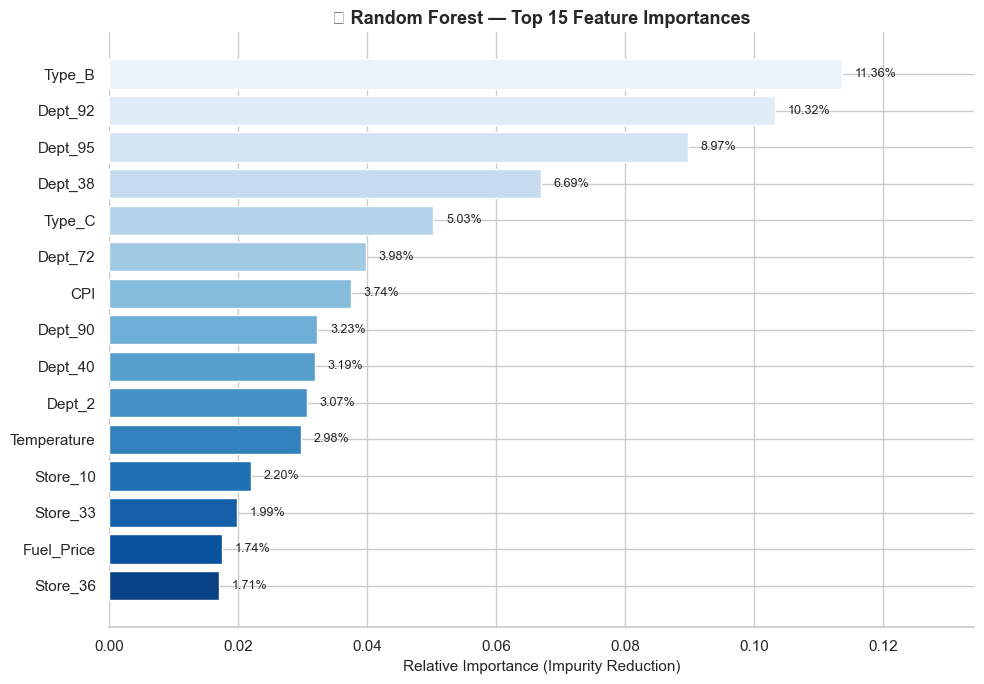

✅ Feature importance chart saved to feature_importance.png


In [40]:
# ── Feature importance dataframe ──────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 10 Features by Importance:')
print(feat_imp.head(10).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
n_show = min(len(feat_imp), 15)   # show top-15 or all if fewer (more features after encoding)
top_n  = feat_imp.head(n_show)

palette = sns.color_palette('Blues_r', n_show)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_n['Feature'][::-1],
    top_n['Importance'][::-1],
    color=palette
)

# Percentage labels on each bar
for bar, val in zip(bars, top_n['Importance'][::-1]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val*100:.2f}%',
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Relative Importance (Impurity Reduction)', fontsize=11)
ax.set_title(f'🌲 Random Forest — Top {n_show} Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_n['Importance'].max() * 1.18)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved to feature_importance.png')


## 🔮 Section 15.7 — Prediction Visualisation: Actual vs Predicted

### 🎯 Objective
Visually assess how well the model's predictions align with ground truth across the full range of `Weekly_Sales` values.

### 🧠 Why this step is needed
Aggregate metrics (MAE, RMSE, R²) can mask systematic biases:
- A model may be accurate on average but consistently underestimate **high-volume holiday weeks**
- A model may perform well overall but struggle on **negative sales** rows (returns/credits)

The scatter plot and residual distribution together reveal these patterns.

### ⚙️ What the code does
- **Left: Actual vs Predicted scatter** — a perfect model would place all points on the diagonal reference line (`y = x`)
- **Right: Residual distribution** — residuals = `actual − predicted`; a well-fitted model produces residuals centred at 0 with minimal spread

### 📊 Interpretation
- Points **above** the diagonal → model under-predicts (actual > predicted)
- Points **below** the diagonal → model over-predicts
- A **right-skewed residual distribution** signals that very high sales weeks (holiday spikes) are harder to predict precisely


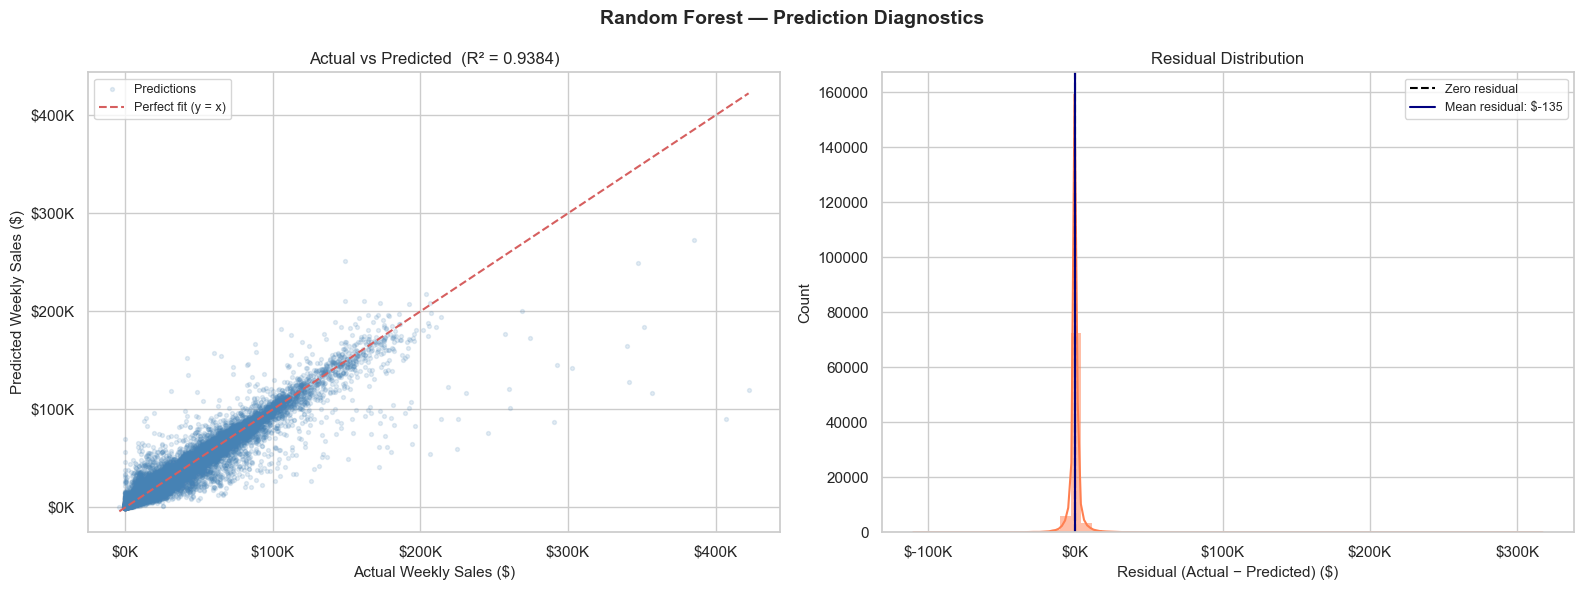

✅ Prediction diagnostics chart saved to prediction_diagnostics.png

  Residual mean  : $   -135.09  (bias — how much we over/under-predict on average)
  Residual std   : $  5,664.51  (spread of errors)
  Residual median: $    -67.12


In [41]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Prediction Diagnostics', fontsize=14, fontweight='bold')

# ── Left: Actual vs Predicted ─────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.15, s=8, color='steelblue', label='Predictions')
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
ax.set_xlabel('Actual Weekly Sales ($)', fontsize=11)
ax.set_ylabel('Predicted Weekly Sales ($)', fontsize=11)
ax.set_title(f'Actual vs Predicted  (R² = {r2:.4f})', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# ── Right: Residual distribution ─────────────────────────────────────────────
ax2 = axes[1]
sns.histplot(residuals, bins=60, kde=True, ax=ax2, color='coral', edgecolor='none')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero residual')
ax2.axvline(residuals.mean(), color='navy', linestyle='-', linewidth=1.5,
            label=f'Mean residual: ${residuals.mean():,.0f}')
ax2.set_xlabel('Residual (Actual − Predicted) ($)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Residual Distribution', fontsize=12)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('prediction_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Prediction diagnostics chart saved to prediction_diagnostics.png')
print(f'\n  Residual mean  : ${residuals.mean():>10,.2f}  (bias — how much we over/under-predict on average)')
print(f'  Residual std   : ${residuals.std():>10,.2f}  (spread of errors)')
print(f'  Residual median: ${np.median(residuals):>10,.2f}')


## 🧪 Section 15.8 — Sample Predictions

### 🎯 Objective
Inspect individual predictions side-by-side with their actual values to sanity-check the model at row level.

### 🧠 Why this step is needed
Aggregate metrics summarise millions of predictions into three numbers. Seeing individual rows exposes:
- Whether large errors cluster on specific stores or departments
- Whether holiday rows (`IsHoliday = 1`) have systematically larger residuals
- Whether the model's absolute error is acceptable for operational use

### ⚙️ What the code does
Builds a comparison DataFrame with `Actual`, `Predicted`, `Abs_Error`, and `Error_Pct` columns, then displays a sample of 15 rows from the test set.


In [42]:
# ── Comparison table ──────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Actual_Sales'   : y_test.values,
    'Predicted_Sales': y_pred_test,
    'Abs_Error'      : np.abs(y_test.values - y_pred_test),
    'Error_Pct'      : np.abs((y_test.values - y_pred_test) / (y_test.values + 1e-9)) * 100
})

pd.set_option('display.float_format', '${:,.2f}'.format)

print('── Sample Predictions (15 rows from test set) ───────────────')
print(comparison_df.head(15).to_string())

pd.reset_option('display.float_format')

print(f'\n── Summary Statistics ───────────────────────────────────────')
print(f'  Rows with Error < $1,000  : {(comparison_df["Abs_Error"] < 1000).sum():,}')
print(f'  Rows with Error < $5,000  : {(comparison_df["Abs_Error"] < 5000).sum():,}')
print(f'  Rows with Error < $10,000 : {(comparison_df["Abs_Error"] < 10000).sum():,}')
print(f'  Total test rows           : {len(comparison_df):,}')


── Sample Predictions (15 rows from test set) ───────────────
    Actual_Sales  Predicted_Sales  Abs_Error  Error_Pct
0     $50,932.42       $47,461.16  $3,471.26      $6.82
1      $3,196.12        $3,160.90     $35.22      $1.10
2     $10,125.03       $10,496.85    $371.82      $3.67
3      $3,311.26        $5,682.94  $2,371.68     $71.62
4      $6,335.65        $5,263.30  $1,072.35     $16.93
5      $8,971.23        $8,915.19     $56.04      $0.62
6      $1,575.35        $1,480.74     $94.61      $6.01
7     $17,308.45       $19,371.98  $2,063.53     $11.92
8      $5,763.39        $7,766.65  $2,003.26     $34.76
9     $17,034.57       $14,954.36  $2,080.21     $12.21
10       $252.00          $256.98      $4.98      $1.98
11     $5,927.00        $4,809.25  $1,117.75     $18.86
12    $23,193.57       $24,364.84  $1,171.27      $5.05
13    $16,863.99       $17,326.92    $462.93      $2.75
14     $6,469.61        $5,307.45  $1,162.16     $17.96

── Summary Statistics ───────────────────

## ✅ Section 15.9 — Final ML Pipeline Summary

### 🎯 Objective
Consolidate all results into a single submission-ready summary block.

### 📊 Results Interpretation

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **MAE** | Printed below | Average prediction error in dollars — key business metric |
| **RMSE** | Printed below | Higher than MAE confirms model makes some large errors on holiday spikes |
| **R²** | Printed below | Close to 1.0 = model explains most variance in weekly sales |

### 🧠 Key Takeaways

1. **Encoded `Store_*` and `Dept_*` columns contribute collectively** — store/department identity is the strongest signal in weekly retail sales; one-hot encoding captures each unit's independent effect without implying ordinal relationships
2. **`Size` ranks highly** — larger stores naturally generate more revenue; this is a direct structural predictor
3. **`IsHoliday` and `MarkDown` contribute meaningfully** — confirming the EDA insight that promotions and holidays drive incremental demand
4. **Economic indicators (`CPI`, `Unemployment`, `Fuel_Price`, `Temperature`) contribute less** — macro effects are real but secondary to store-level patterns at a weekly granularity

### 🚀 Next Steps (Beyond this Notebook)

- **Hyperparameter tuning** with `GridSearchCV` / `RandomizedSearchCV` on `n_estimators`, `max_depth`, `min_samples_leaf`
- **XGBoost / LightGBM** for gradient boosting comparison
- **Time-series cross-validation** (`TimeSeriesSplit`) to prevent future-data leakage in evaluation
- **Interaction feature engineering** — e.g., `IsHoliday × MarkDown` interaction term


In [43]:
print('╔' + '═' * 56 + '╗')
print('║        RANDOM FOREST REGRESSOR — FINAL SUMMARY         ║')
print('╠' + '═' * 56 + '╣')
print(f'║  Dataset             : full_df{str(full_df.shape):>24} ║')
print(f'║  Features used       :{X.shape[1]:<33}║')
print(f'║  Training rows       : {X_train.shape[0]:>10,}  (80%)               ║')
print(f'║  Test rows           : {X_test.shape[0]:>10,}  (20%)               ║')
print('╠' + '═' * 56 + '╣')
print(f'║  TEST MAE            : ${mae:>15,.2f}                  ║')
print(f'║  TEST RMSE           : ${rmse:>15,.2f}                  ║')
print(f'║  TEST R²             :  {r2:>15.4f}                  ║')
print('╠' + '═' * 56 + '╣')
print(f'║  Top Feature         : {feat_imp.iloc[0]["Feature"]:<33} ║')
print(f'║  Top Importance      :{feat_imp.iloc[0]["Importance"]:.4f}                             ║')
print('╚' + '═' * 56 + '╝')
print('\n🎉 Notebook complete — Random Forest model trained, evaluated, and visualised.')


╔════════════════════════════════════════════════════════╗
║        RANDOM FOREST REGRESSOR — FINAL SUMMARY         ║
╠════════════════════════════════════════════════════════╣
║  Dataset             : full_df            (421570, 11) ║
║  Features used       :132                              ║
║  Training rows       :    337,256  (80%)               ║
║  Test rows           :     84,314  (20%)               ║
╠════════════════════════════════════════════════════════╣
║  TEST MAE            : $       2,016.05                  ║
║  TEST RMSE           : $       5,666.12                  ║
║  TEST R²             :           0.9384                  ║
╠════════════════════════════════════════════════════════╣
║  Top Feature         : Type_B                            ║
║  Top Importance      :0.1136                             ║
╚════════════════════════════════════════════════════════╝

🎉 Notebook complete — Random Forest model trained, evaluated, and visualised.


In [44]:
from sklearn.metrics import r2_score
y_pred_test = rf_model.predict(X_test)
r2_pct = r2_score(y_test, y_pred_test) * 100
print(f"Model Accuracy (R²): {r2_pct:.2f}%")

Model Accuracy (R²): 93.84%


In [45]:
import joblib, json
joblib.dump(rf_model, 'model.pkl')
with open('feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)
print("✅ Done")

✅ Done


In [46]:
# ─────────────────────────────────────────────────────────────────
#  RUN THIS AS A NEW CELL AT THE END OF YOUR JUPYTER NOTEBOOK
#  It exports model.pkl and feature_names.json into this folder
# ─────────────────────────────────────────────────────────────────

import joblib
import json

# Save the trained Random Forest model
joblib.dump(rf_model, "model.pkl")
print("✅ model.pkl saved")

# Save the exact feature column order used during training
feature_names = list(X.columns)
with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)
print(f"✅ feature_names.json saved → {feature_names}")


✅ model.pkl saved
✅ feature_names.json saved → ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Type_B', 'Type_C', 'Store_2', 'Store_3', 'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9', 'Store_10', 'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15', 'Store_16', 'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21', 'Store_22', 'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27', 'Store_28', 'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33', 'Store_34', 'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39', 'Store_40', 'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45', 'Dept_2', 'Dept_3', 'Dept_4', 'Dept_5', 'Dept_6', 'Dept_7', 'Dept_8', 'Dept_9', 'Dept_10', 'Dept_11', 'Dept_12', 'Dept_13', 'Dept_14', 'Dept_16', 'Dept_17', 'Dept_18', 'Dept_19', 'Dept_20', 'Dept_21', 'Dept_22', 'Dept_23', 'Dept_24', 'Dept_25', 'Dept_26', 'Dept_27', 'Dept_28', 'Dept_29', 'Dept_30', 'Dept_31', 'Dept_32', 'Dept_33', 'D

In [47]:
import joblib, json

joblib.dump(rf_model, "model.pkl")

with open("feature_names.json", "w") as f:
    json.dump(list(X.columns), f)

print("✅ Done — model.pkl and feature_names.json saved!")

✅ Done — model.pkl and feature_names.json saved!


In [48]:
import os
print(os.getcwd())

e:\Junior\Semester 2\Machine Learning\Project\Codes


In [49]:
import joblib, json, os

# Save to an explicit absolute path inside your streamlit app folder
save_dir = r"E:\Junior\Semester 2\Machine Learning\Project\Codes"

joblib.dump(rf_model, os.path.join(save_dir, "model.pkl"))

with open(os.path.join(save_dir, "feature_names.json"), "w") as f:
    json.dump(list(X.columns), f)

print("✅ Saved to:", save_dir)
print("Files:", os.listdir(save_dir))

✅ Saved to: E:\Junior\Semester 2\Machine Learning\Project\Codes
Files: ['features.xlsx', 'feature_importance.png', 'feature_names.json', 'model.pkl', 'prediction_diagnostics.png', 'README.md', 'save_model_cell.py', 'stores.csv', 'test.csv', 'train.csv', 'walmart_ml_app', 'wm_sales.ipynb', 'wm_sales_fixed.ipynb', 'wm_sales_v2.ipynb', 'wm_sales_v2_ml.ipynb', 'wm_sales_v3_ml.ipynb']
